In [13]:
# Install the required libraries quietly
!pip install datasets pandas -q

import pandas as pd
from datasets import load_dataset

# ==========================================
# PHASE 1: Data Acquisition & Target Selection
# ==========================================
print("📥 Downloading 200k production dataset from Hugging Face...")
hf_dataset = load_dataset("lanretto/discourse_quality", data_files="full_labeled_flattened.csv", split="train")

# Convert to pandas so we can easily clean and inspect it
df = hf_dataset.to_pandas()

# Define our 6 target dimensions for the Multi-Output model
target_cols = [
    'level_of_justification',
    'respect_towards_demands',
    'respect_towards_counterarguments',
    'content_of_justification',
    'respect_towards_groups',
    'constructive_politics'
]

# Keep only the comment text and our 6 targets
# We drop any rows that have missing values in these specific columns to be safe
df_model = df[['comment'] + target_cols].dropna()

# Ensure all comments are strictly formatted as strings
df_model['comment'] = df_model['comment'].astype(str)

print(f"✅ Data loaded successfully! Total valid rows: {len(df_model)}")

# Show a quick peek at the dataframe to verify all 6 columns are lined up
#from IPython.display import display
#display(df_model.head())

📥 Downloading 200k production dataset from Hugging Face...
✅ Data loaded successfully! Total valid rows: 205850


In [14]:
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import AutoTokenizer

# ==========================================
# PHASE 2: The "Zip" Transformation & Splitting
# ==========================================
print("🔄 Merging the 6 dimensions into a single list of labels...")

# This Pandas shortcut is the equivalent of the "zip" trick.
# It takes the 6 columns and bundles them into a single list for each row.
df_model['labels'] = df_model[target_cols].values.tolist()

print("🔀 Performing standard 80/20 Train/Test split...")
# We use a standard split here because we cannot easily stratify 6 continuous dimensions at once.
train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42
)

# Convert our prepared dataframes back into Hugging Face Dataset objects
# We only need the text and our new bundled 'labels' column!
train_dataset = Dataset.from_pandas(train_df[['comment', 'labels']], preserve_index=False)
test_dataset = Dataset.from_pandas(test_df[['comment', 'labels']], preserve_index=False)

# ==========================================
# PHASE 3: Tokenization & PyTorch Formatting
# ==========================================
print("⚙️ Loading the bert-base-uncased Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples['comment'], padding="max_length", truncation=True, max_length=128)

print("Tokenizing data (this takes a few seconds)...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# THE CRITICAL STEP: We strip away everything except the required columns and lock them as PyTorch tensors.
print("🧱 Formatting datasets to exact PyTorch tensors...")
tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("\n✅ Phase 2 & 3 Complete! Data is perfectly formatted for the Multi-Output Model.")

# Let's peek at the first row's label to prove the 6 numbers are perfectly bundled into a PyTorch tensor
print("\nProof of formatting (First row's label tensor):")
print(tokenized_train[0]['labels'])

🔄 Merging the 6 dimensions into a single list of labels...
🔀 Performing standard 80/20 Train/Test split...
⚙️ Loading the bert-base-uncased Tokenizer...
Tokenizing data (this takes a few seconds)...


Map: 100%|██████████| 41170/41170 [00:03<00:00, 13061.61 examples/s]

🧱 Formatting datasets to exact PyTorch tensors...

✅ Phase 2 & 3 Complete! Data is perfectly formatted for the Multi-Output Model.

Proof of formatting (First row's label tensor):
tensor([-0.6000, -0.6000, -0.6000, -0.6000, -0.4000, -0.6000])


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🧠 Loading the BERT Master Model (num_labels=6, problem_type='regression')...
🔗 Connecting to Weights & Biases...



🚀 Starting Multi-Output Regression Training! Watch your W&B dashboard...


Step,Training Loss,Validation Loss,Mse Level Of Justification,Mse Respect Towards Demands,Mse Respect Towards Counterarguments,Mse Content Of Justification,Mse Respect Towards Groups,Mse Constructive Politics,Mse Overall
200,0.077300,0.061301,0.058602,0.069822,0.065911,0.074425,0.041646,0.057399,0.061301
400,0.061000,0.057162,0.053156,0.063961,0.061922,0.071477,0.038992,0.053467,0.057162
600,0.058700,0.055103,0.051125,0.061731,0.060111,0.068458,0.037622,0.051573,0.055103
800,0.054500,0.054491,0.050746,0.060831,0.059305,0.068057,0.037249,0.050758,0.054491
1000,0.052900,0.053683,0.049681,0.060064,0.058346,0.067066,0.036623,0.050317,0.053683
1200,0.051900,0.054595,0.050304,0.061902,0.059252,0.067761,0.037203,0.051152,0.054595
1400,0.050000,0.053035,0.049016,0.059176,0.057854,0.066255,0.036273,0.049637,0.053035
1600,0.049000,0.052775,0.048884,0.059123,0.057796,0.065817,0.035735,0.049295,0.052775
1800,0.048600,0.052741,0.048754,0.058979,0.057667,0.065954,0.035725,0.049368,0.052741


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▁▂▂▂▂▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇████
eval/loss,█▅▃▂▂▃▁▁▁
eval/mse_OVERALL,█▅▃▂▂▃▁▁▁
eval/mse_constructive_politics,█▅▃▂▂▃▁▁▁
eval/mse_content_of_justification,█▆▃▃▂▃▁▁▁
eval/mse_level_of_justification,█▄▃▂▂▂▁▁▁
eval/mse_respect_towards_counterarguments,█▅▃▂▂▂▁▁▁
eval/mse_respect_towards_demands,█▄▃▂▂▃▁▁▁
eval/mse_respect_towards_groups,█▅▃▃▂▃▂▁▁
eval/runtime,▁▂▆▄▅▅▃▄█
+21,...



✅ Training Complete! (Model kept in memory, not saved to disk)

📊 Extracting data from Trainer history and plotting...


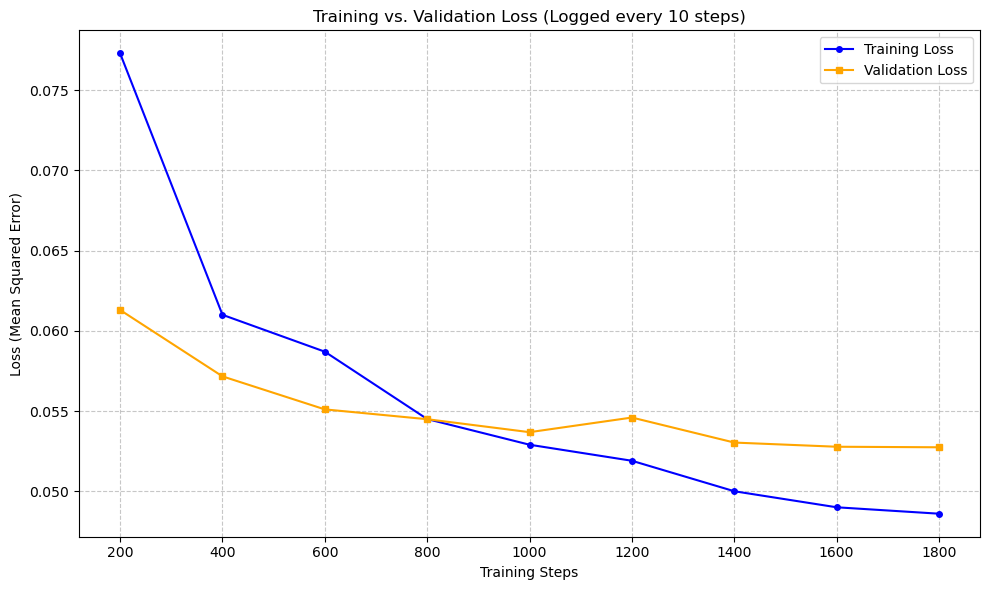

In [15]:
import os
import wandb
import numpy as np
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# ==========================================
# PHASE 4: Model Architecture (Multi-Output)
# ==========================================
print("🧠 Loading the BERT Master Model (num_labels=6, problem_type='regression')...")

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=6,
    problem_type="regression" # THE MAGIC TRICK: Forces MSE loss across all 6 outputs
)

# ==========================================
# PHASE 5: The Multi-Output Grader
# ==========================================
# We need our column names so W&B knows exactly what to name each graph
target_cols = [
    'level_of_justification', 'respect_towards_demands', 'respect_towards_counterarguments',
    'content_of_justification', 'respect_towards_groups', 'constructive_politics'
]

from sklearn.metrics import mean_squared_error

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    metrics = {}
    
    total_mse = 0
    
    # Loop through all 6 dimensions
    for i, col_name in enumerate(target_cols):
        # Calculate Validation MSE for this specific dimension
        mse = mean_squared_error(labels[:, i], logits[:, i])
        
        # Log it
        metrics[f"mse_{col_name}"] = mse
        total_mse += mse
        
    # Log the overall average Validation MSE
    metrics["mse_OVERALL"] = total_mse / 6
    
    return metrics

import os
import wandb
import matplotlib.pyplot as plt
from transformers import TrainingArguments, Trainer

# ==========================================
# PHASE 6: W&B Integration & Training
# ==========================================
print("🔗 Connecting to Weights & Biases...")
os.environ["WANDB_API_KEY"] = "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"

wandb.init(
    entity="niyimoluga85-universty-of-technology-graz",
    project="DQI_Multi_Regression",
    name="bert_6_dim_step10_test",
)

training_args = TrainingArguments(
    output_dir="./results_master_model_200k",
    eval_strategy="steps",           
    logging_strategy="steps", 
    save_strategy="steps",           # Turn saving back on!
    eval_steps=200,                  # Evaluate every 200 steps
    logging_steps=200,               # Log every 200 steps
    save_steps=200,                  # Save a checkpoint every 200 steps
    save_total_limit=2,              # CRITICAL: Only keep the 2 most recent checkpoints
    learning_rate=2e-5,
    per_device_train_batch_size=64,  # Tripled your batch size for the 48GB L40S!
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,     # Keep the absolute best version at the end
    metric_for_best_model="mse_OVERALL", 
    greater_is_better=False,
    report_to="wandb" 
)

import torch
import torch.nn as nn
from transformers import Trainer
import wandb

# 1. Define the interceptor class
class PureMSETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        loss_fct = nn.MSELoss(reduction="none")
        per_dim_errors = loss_fct(logits, labels)
        
        mse_per_dim = per_dim_errors.mean(dim=0) 
        master_mse = mse_per_dim.mean()
        
        if self.state.global_step % self.args.logging_steps == 0 and self.args.should_log:
            log_dict = {}
            for i, col_name in enumerate(target_cols):
                log_dict[f"train/mse_{col_name}"] = mse_per_dim[i].item()
                
            log_dict["train/mse_OVERALL"] = master_mse.item()
            wandb.log(log_dict, step=self.log(log_dict))
            
        return (master_mse, outputs) if return_outputs else master_mse

# 2. Initialize using YOUR new class instead of the default one!
trainer = PureMSETrainer( # <--- The swap happens right here!
    model=model,
    args=training_args, 
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics, # (This is the updated Validation MSE grader)
)

print("\n🚀 Starting Multi-Output Regression Training! Watch your W&B dashboard...")
trainer.train()
wandb.finish()

print("\n✅ Training Complete! (Model kept in memory, not saved to disk)")

# ==========================================
# EXTRA: Plotting Loss Directly in Colab
# ==========================================
print("\n📊 Extracting data from Trainer history and plotting...")

# 1. Crack open the hidden diary
history = trainer.state.log_history

train_steps, train_loss = [], []
eval_steps, eval_loss = [], []

# 2. Sort the diary entries into lists
for log in history:
    if 'loss' in log: # This means it's a Training Loss log
        train_steps.append(log['step'])
        train_loss.append(log['loss'])
    elif 'eval_loss' in log: # This means it's a Validation Loss log
        eval_steps.append(log['step'])
        eval_loss.append(log['eval_loss'])

# 3. Draw the beautiful graph
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label='Training Loss', color='blue', marker='o', markersize=4)
plt.plot(eval_steps, eval_loss, label='Validation Loss', color='orange', marker='s', markersize=4)

plt.xlabel('Training Steps')
plt.ylabel('Loss (Mean Squared Error)')
plt.title('Training vs. Validation Loss (Logged every 10 steps)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot right here in Colab!
plt.show()


📊 Cleaning the 'Frozen Time' glitch and drawing the grid...


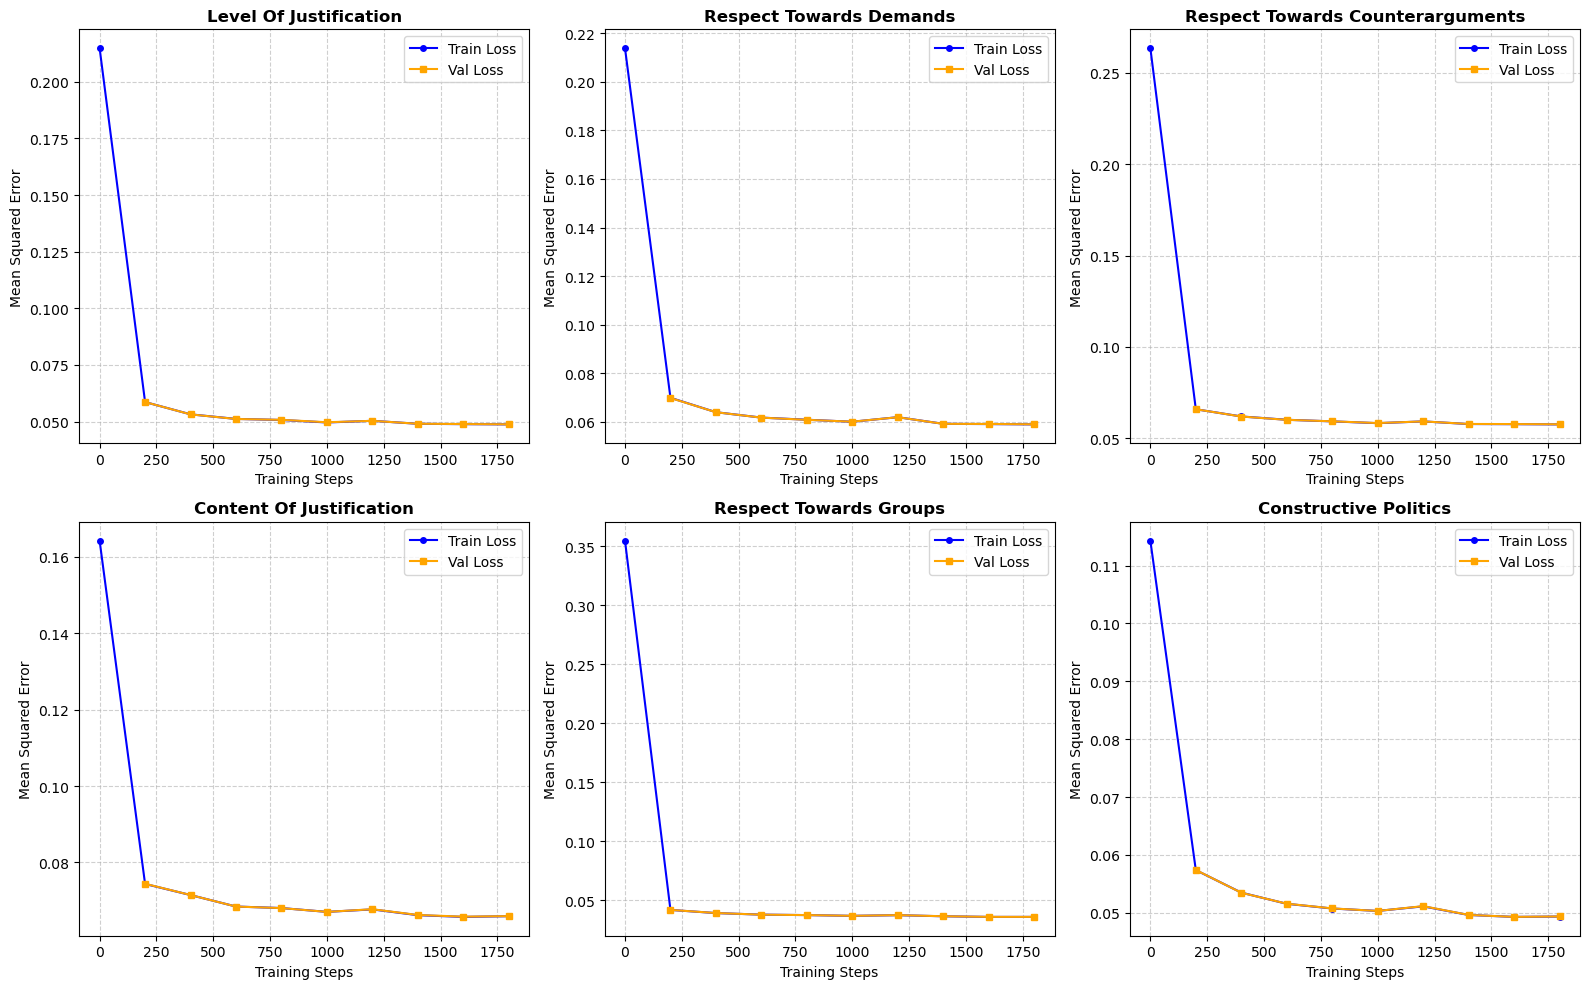

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# EXTRA: Plotting the 6 Dimensions (Cleaned)
# ==========================================
print("\n📊 Cleaning the 'Frozen Time' glitch and drawing the grid...")

history = trainer.state.log_history
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten() 

for i, col_name in enumerate(target_cols):
    
    # 1. Grab the raw, glitchy training data
    raw_train_steps = [log['step'] for log in history if f'train/mse_{col_name}' in log]
    raw_train_mse = [log[f'train/mse_{col_name}'] for log in history if f'train/mse_{col_name}' in log]
    
    # 2. Grab the clean validation data
    eval_steps = [log['step'] for log in history if f'eval_mse_{col_name}' in log]
    eval_mse = [log[f'eval_mse_{col_name}'] for log in history if f'eval_mse_{col_name}' in log]
    
    # 3. THE FIX: Average the duplicate blue dots at each step into a single clean dot!
    train_dict = {}
    for step, val in zip(raw_train_steps, raw_train_mse):
        if step not in train_dict:
            train_dict[step] = []
        train_dict[step].append(val)
        
    clean_train_steps = sorted(list(train_dict.keys()))
    clean_train_mse = [np.mean(train_dict[s]) for s in clean_train_steps]
    
    # Grab the current mini-plot
    ax = axes[i]
    
    # Draw the newly cleaned Blue Training line and Orange Validation line
    if clean_train_steps:
        ax.plot(clean_train_steps, clean_train_mse, label='Train Loss', marker='o', markersize=4, color='blue', linewidth=1.5)
    if eval_steps:
        ax.plot(eval_steps, eval_mse, label='Val Loss', marker='s', markersize=4, color='orange', linewidth=1.5)
    
    # Format the title
    clean_title = col_name.replace('_', ' ').title()
    ax.set_title(clean_title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('Mean Squared Error')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()